# OptionA - HSBC(HSBA.L) vs. S&P 500: 2024 Peformance Analysis

> ### Setup instructions
> Before running this workbook, you need to install the following packages:
> `!pip install yfinance`


## Introduction
This project analyzes the performance of HSBC Holdings plc stock (ticker: HSBA.L, listed on the London Stock Exchange) in comparison with the S&P 500 index (ticker: ^GSPC, representing the overall U.S. equity market). Using historical price data downloaded from Yahoo Finance via the yfinance library, the study focuses on how HSBC performed relative to the broader market during 2024.

By using the S&P 500 as a market benchmark, this project evaluates HSBC’s price trend, total return, volatility and risk-adjusted performance. These metrics provide a clear comparison between a single financial stock and a diversified market index, highlighting how HSBC behaves in terms of growth, risk and overall performance.

## Topics

* Source Data
* Data Cleaning
* Price Trend
* Return
* Volatility
* Sharpe Ratio

# Source data
* load adjusted closing prices for HSBC and the S&P 500
* use yfinance to download the historical data
* check the first few rows to make sure the data loaded correctly
* look at the dataset structure to confirm completeness

In [18]:
# Install yfinance packages
!pip install yfinance
import yfinance as yf

# Ticker symbol for HSBC and S&P 500 index
tickers = ['HSBA.L', '^GSPC']

# Download adjusted closing price for stock HSBC.L and S&P 500 index during 2024
datas = yf.download(tickers, start="2024-01-01", end="2025-01-01", auto_adjust=True)['Close']

# Display first 5 rows
display(datas.head())

# Basic data imformation
datas.info()

[*********************100%***********************]  2 of 2 completed

Ticker,HSBA.L,^GSPC
Date,,
2024-01-02,629.557434,4742.830078
2024-01-03,624.465027,4704.810059
2024-01-04,631.554260,4688.680176
2024-01-05,633.351624,4697.240234
2024-01-08,639.043213,4763.540039


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 258 entries, 2024-01-02 to 2024-12-31
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HSBA.L  254 non-null    float64
 1   ^GSPC   252 non-null    float64
dtypes: float64(2)
memory usage: 6.0 KB


The preview of the dataset shows that the price data for HSBC and the S&P 500 has been loaded correctly. The first few rows confirm that the dataset contains daily adjusted closing prices for 2024 and the info output indicates that both series are mostly complete with only a few missing values. Overall, the structure looks consistent and properly formatted, so the dataset is ready for the cleaning stage.

# Data Cleaning

* check for missing values in the dataset
* remove rows that contain null values
* confirm that no missing values remain after cleaning
* review the dataset structure before moving on to analysis

In [15]:
# Count null values in two tickers
print("null values for HSBA.L = ", datas["HSBA.L"].isnull().sum())
print("null values for ^GSPC = ", datas["^GSPC"].isnull().sum(), "\n")

# Remove the missing values
datas_clean = datas.dropna()

# Confrim that null values have been removed
print("missing values after cleaning:\n", datas_clean.isnull().sum(), "\n")

# Data imformation after cleaning
datas_clean.info()

null values for HSBA.L =  4
null values for ^GSPC =  6 

missing values after cleaning:
 Ticker
HSBA.L    0
^GSPC     0
dtype: int64 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2024-01-02 to 2024-12-31
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HSBA.L  248 non-null    float64
 1   ^GSPC   248 non-null    float64
dtypes: float64(2)
memory usage: 5.8 KB


Before cleaning, there were 4 missing values in the HSBC series and 6 in the S&P 500 series. 
Since the number of missing entries was small, I removed the affected rows to keep the data consistent. After cleaning, 248 complete trading days remained, giving me a reliable dataset to use for the following analysis.

# Price Trend

* start both price series at the same level (100) to make sure their movments can be compared directly
* using a normalized index to remove the effect of different price levels and focuses only on relative performance
* plot how HSBC and the S&P 500 change over time during 2024
* observe which one grew faster, which one dropped more, and how their volatility differs
* use the trend to compare HSBC’s overall performance with borader market

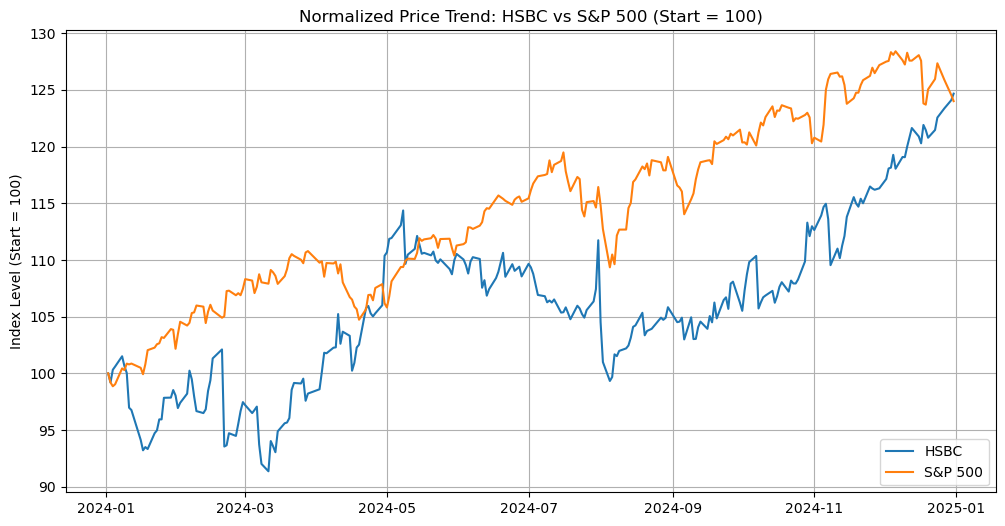

In [16]:
import matplotlib.pyplot as plt

# Normalize to start at 100
first_day = datas_clean.iloc[0]
normalized = datas_clean / first_day * 100

# Create a chart
fig, ax = plt.subplots(figsize=(12, 6))

# Add series
plt.plot(normalized.index, normalized['HSBA.L'], label='HSBC')
plt.plot(normalized.index, normalized['^GSPC'], label='S&P 500')

# Add titles
ax.set_title('Normalized Price Trend: HSBC vs S&P 500 (Start = 100)')
ax.set_ylabel('Index Level (Start = 100)')

# Add grid lines
ax.legend(loc='lower right')
ax.grid(True)

From the normalized price trend chart, we can see that:

* The S&P 500 shows a steady and consistent rise throughout 2024.
* HSBC’s price path is more uneven with several noticeable dips before recovering later in the year
* Although HSBC ends the year above where it started, its performance is volatile compared with the market index
* When compared with the S&P 500 index, HSBC’s price trend shows that it lagged behind the broader market for most of the year.

Overall, the S&P 500 displays stronger and more stable growth, while HSBC’s performance is positive but noticeably less steady. This suggests that HSBC did not fully keep pace with the market’s upward momentum during 2024.

# Return
* Total Return
  - calculate annual return for HSBC and the S&P 500
  - use a bar chart to compare their overall performance
* Daily Return 
  - calculate daily percentage returns for both series
  - use a histogram to show how the returns distributed

## Total Return
* calculate the annual return for HSBC and the S&P 500
* apply the formula: Final price/Initial price - 1
* compare their performance over the year 2024
* identify which asset generated a higher overall gain
* present the reults using a simple bar chart for easy comparision

Ticker
HSBA.L    0.246726
^GSPC     0.240110
dtype: float64

Text(0.5, 0, 'HSBA.L = HSBC stock  |  ^GSPC = S&P 500 index')

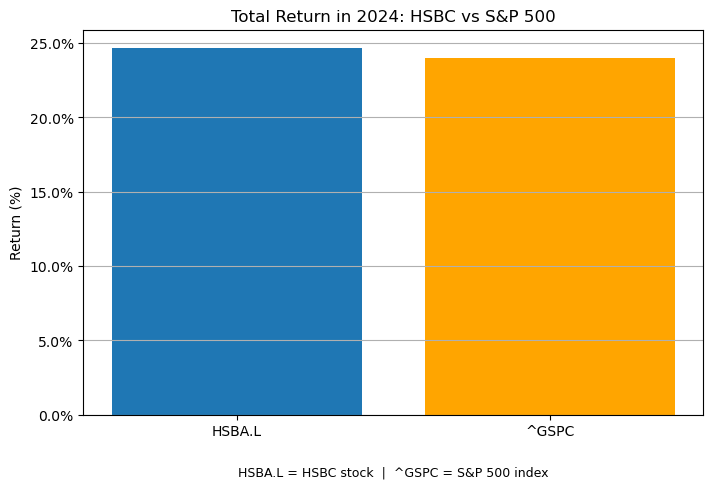

In [17]:
import numpy as np
import matplotlib.ticker as mtick

# Total_return is a Series with HSBA.L and ^GSPC
total_return = datas_clean.iloc[-1] / datas_clean.iloc[0] - 1

# Preview the numeric results
display(total_return)

# Convert to percentage
total_return_percent = total_return*100

# Create a bar chart
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(total_return.index, total_return_percent, color=['#1f77b4','orange'])

# Add titles
plt.ylabel('Return (%)')
plt.title("Total Return in 2024: HSBC vs S&P 500")

# Formatting of axis
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

# Add grid lines
ax.grid(axis='y')

# Explain x-axis label
ax.set_xlabel("HSBA.L = HSBC stock  |  ^GSPC = S&P 500 index", fontsize=9, labelpad=20)

The bar chart shows that both HSBC and the S&P 500 delivered strong returns in 2024. HSBC finished the year with a return of about 24.67%, slightly above the S&P 500’s 24.01%. Although the gap is small, it still suggests that HSBC performed marginally better than the overall market. In general, HSBC offered a solid investment outcome relative to the broader market index during the year.

## Daily Return

* compute daily percentage returns based on price changes between consecutive trading days
* use a histogram to visualize how frequently different return levels occur
* check whether HSBC shows larger swings or more extreme daily movements
* compare how tightly the S&P 500 returns cluster around zero
* use the distribution shape to understand short-term risk for both HSBC and the market index

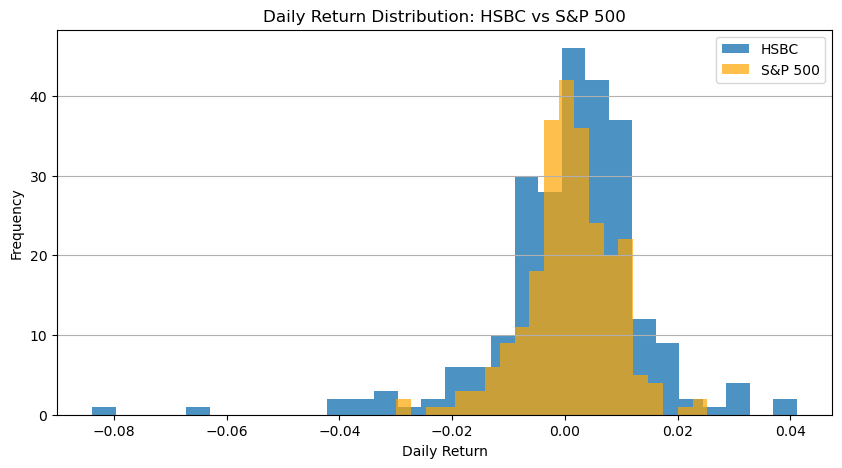

In [12]:
# Calculate daily return
returns = datas_clean.pct_change().dropna()

# Create chart
fig, ax = plt.subplots(figsize=(10,5))

# HSBC histogram
ax.hist(returns["HSBA.L"], bins='auto', alpha=0.8, label='HSBC', color='#1f77b4')

# S&P500 histogram
ax.hist(returns["^GSPC"], bins='auto', alpha=0.7, label='S&P 500', color='orange')

# Add title and labels
ax.set_title("Daily Return Distribution: HSBC vs S&P 500")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")

# Add legend and grid lines
ax.legend(loc='upper right')
ax.grid(axis='y')

From the histogram, we can see that:

* HSBC has a wider distribution with heavier tails, meaning its daily returns move around more and show higher short-term volatility.
* The S&P 500’s returns cluster more tightly around zero, suggesting more stable day-to-day movements.
* HSBC experiences more noticeable extreme return events than the market index.
* Overall, the shape of the distribution indicates that HSBC carries more idiosyncratic risk compared with the diversified S&P 500.

Overall, using the market index as the benchmark, HSBC’s daily returns fluctuate more widely throughout the year, while the S&P 500 remains relatively steady. This shows that investing in HSBC involves higher short-term uncertainty than investing in the broader market.

# Volatility

* calculate daily volatility using the standard deviation of returns
* apply a 30-day rolling window to show how risk changes throughout the year
* compare HSBC’s volatility with the S&P 500 as the market benchmark
* identify periods where HSBC becomes noticeably more unstable than the index
* use the volatility trend to understand how each asset behaves in terms of short-term risk

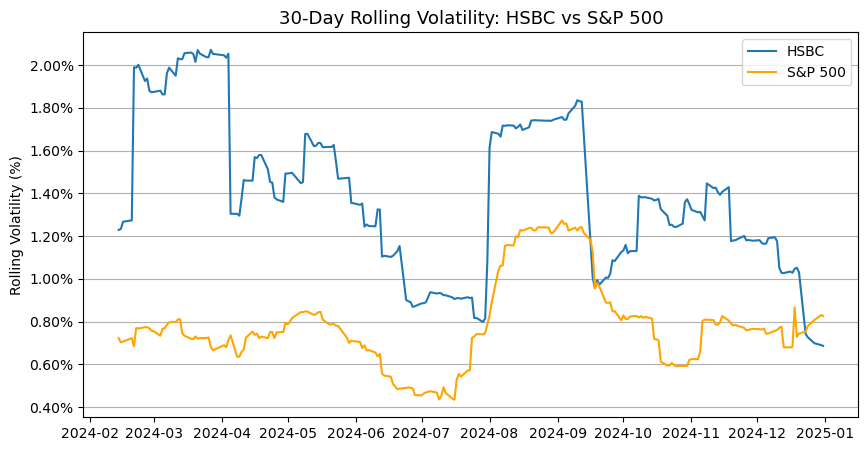

In [11]:
# Calculate 30-day rolling volatility (in percentage terms)
rolling_vol = returns.rolling(window=30).std() * 100

# Create a chart
fig, ax = plt.subplots(figsize=(10,5))

# Add series
ax.plot(rolling_vol.index, rolling_vol["HSBA.L"], label="HSBC", color="#1f77b4")
ax.plot(rolling_vol.index, rolling_vol["^GSPC"], label="S&P 500", color="orange")

# Add titles
ax.set_title("30-Day Rolling Volatility: HSBC vs S&P 500", fontsize=13)
ax.set_ylabel("Rolling Volatility (%)")

# Add legend and grid
ax.legend(loc="upper right")
ax.grid(axis="y")

# Formatting of axis
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

From the line chart, we can see that:
* HSBC’s volatility stays consistently higher than the S&P 500, meaning its daily returns move around more.
* The S&P 500 shows a much smoother and more stable pattern, with smaller fluctuations across the year.
* HSBC also experiences several noticeable spikes in volatility, while the broader market remains relatively steady.
* This indicates that HSBC carries higher short-term risk than the market index, which is expected since the S&P 500 is a diversified benchmark, while HSBC is a single stock.

Overall, HSBC shows stronger and more frequent movements, whereas the S&P 500 stays more stable throughout the year. This highlights that HSBC has higher day-to-day risk and a more volatile performance compared with the broader market environment.

# Sharpe Ratio

* calculate risk-adjusted performance using Sharpe ratio
* compare whether HSBC or the S&P 500 delivers better return per unit of risk
* use the formula: (average daily return – risk-free rate) / daily return volatility
* assume a risk-free rate of 0 for simplicity
* present the comparison using a bar chart

sharpe ratio for HSBC( HSBA.L): 0.0714
sharpe ratio for S&P500( HSBA.L): 0.1123


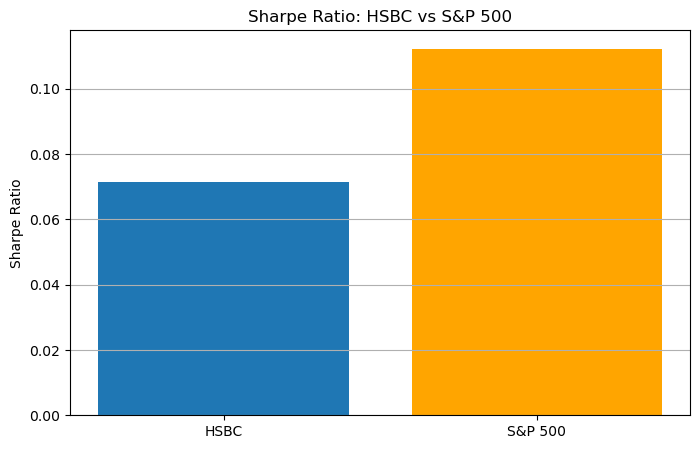

In [13]:
# Calculate mean daily returns
mean_returns = returns.mean()

# Calculate daily volatility
std_returns = returns.std()

# Risk-free rate set to 0
rf = 0

# Compute Sharpe ratio for both seires
sharpe_hsbc = (mean_returns["HSBA.L"] - rf) / std_returns["HSBA.L"]
sharpe_sp500 = (mean_returns["^GSPC"] - rf) / std_returns["^GSPC"]

# Print the sharpe ratio result for two series
print(f"sharpe ratio for HSBC( HSBA.L): {sharpe_hsbc:.4f}")
print(f"sharpe ratio for S&P500( HSBA.L): {sharpe_sp500:.4f}")

# Create chart
fig, ax = plt.subplots(figsize=(8,5))

# Create a bar chart
ax.bar(["HSBC", "S&P 500"], [sharpe_hsbc, sharpe_sp500], color=["#1f77b4", "orange"])

# Add title and label
ax.set_title("Sharpe Ratio: HSBC vs S&P 500")
ax.set_ylabel("Sharpe Ratio")

# Add grid lines
ax.grid(axis='y')

From the bar chart, we can see that:

* The S&P 500 has a much higher Sharpe ratio than HSBC, meaning it delivered stronger returns once risk is taken into account.
* HSBC’s lower ratio indicates that its returns did not fully compensate for the higher volatility it experienced.
* The difference between the two ratios shows that HSBC underperformed the market on a risk-adjusted basis.
* Unlike the diversified S&P 500, HSBC carries more firm-specific risk that is not rewarded by higher returns.

Overall, the comparison suggests that the S&P 500 offered more efficient returns per unit of risk, while HSBC delivered weaker risk-adjusted performance in 2024.

## Conclusion
The comparison between HSBC and the S&P 500 shows that the two performed quite differently in 2024. HSBC had a slightly higher total return, but its price movements were more unstable and showed bigger swings. In contrast, the S&P 500 followed a smoother trend with lower daily volatility.

After considering risk, the S&P 500 performed better overall, which is shown by its higher Sharpe ratio. Because it represents the wider market, this also suggests that HSBC was less efficient than the market once risk is taken into account.

Overall, HSBC produced good growth but with higher short-term uncertainty, while the S&P 500, as the market benchmark, provided more stable and more efficient returns during the year. This means HSBC’s absolute performance was solid, but it was weaker when compared with the overall market.

# Reflection

* as a Developer
* as a Project Manager

## Reflection as a Developer

During this project, I developed my Python and data analysis skills beyond the lecture content. One key improvement was learning to use the yfinance library to download financial data directly from Yahoo Finance. This approach was not covered in class, but it allowed me to obtain data more efficiently when direct downloads from the website were not available.

I also applied methods that were not introduced in lectures, such as rolling volatility, to analyse changes in short-term risk over time. By using online resources, I learned how to implement and visualise this measure, which added depth to my volatility analysis. In addition, I improved the clarity of my visualisations by adjusting transparency in histograms, refining grid usage, and choosing appropriate figure sizes for different charts. When I encountered unfamiliar problems, I searched for solutions and adapted them based on lecture code. This helped me become more confident in independently learning and applying new techniques.

## Reflection as a Project Manager

From a project management perspective, the overall structure followed my original plan, as the analytical framework was clear from the start. However, the time allocation changed significantly. Tasks took longer than expected, so I completed the project gradually over several days rather than in single sessions.

I also worked flexibly instead of strictly following the planned order, starting with simpler tasks before moving on to more complex analysis. After completing each section, I revisited the work to improve accuracy and presentation. Some tasks exceeded the estimated time due to learning new methods, while others were completed more quickly once I gained familiarity. This project improved my understanding of realistic time planning and the importance of iterative refinement in managing analytical work.